# DAI Mission — Proposal A
**Data & AI in Economics | TU Dortmund**

> **Team size:** 2–3 students  
> **Deliverable:** This Jupyter Notebook (proposal → final submission in one file)


## 1. Team

| Role | Name | Student ID |
|------|------|------------|
| Lead | Oliver Ossadnik | *[ID]* |
| Member | Danish Ahmad | *[ID]* |



## 2. Mission Title & Research Question

**Title:** *Irrigation Technology Adoption and Its Effect on Crop Yield: A Treatment-Effect Analysis*

**Research question:**  
Does switching from rainfed to drip or sprinkler irrigation causally increase crop yield (kg per hectare) in Indian agriculture, and for which soil types and crop categories is the effect largest?

**Why it matters:**  
Irrigation infrastructure is one of the largest expenditure items in Indian agricultural policy, yet adoption of modern methods (drip, sprinkler) remains uneven. Knowing the *causal* yield gain from upgrading irrigation — net of climate and soil advantages that may independently attract modern systems — allows policymakers to target subsidies where returns are highest. It also directly bears on water-use efficiency: if drip irrigation raises yield *and* reduces water consumption, the case for public investment is doubly strong.


## 3. Data

**Source(s):**  
- **Dataset:** Enhanced Crop Yield Dataset  
- **Provider:** Mohamed Imad Masood (Kaggle)  
- **URL:** https://www.kaggle.com/datasets/mohamedimadmasoodta/crop-yield-dataset/data  
- **Licence:** CC0 1.0 — Public Domain Dedication

**Unit of observation:** One row represents a single farm plot observation for a specific crop, Indian state, and growing season, augmented with soil and weather attributes.

**Key variables:**

| Variable | Type | Role | Description |
|----------|------|------|-------------|
| `Crop Yield (kg per hectare)` | Continuous | **Target** | Yield outcome |
| `Irrigation_Method` | Categorical | **Treatment** | Drip / Sprinkler / Flood / Rainfed |
| `rainfall` | Continuous | Confounder | Annual rainfall (mm) — affects both irrigation choice and yield |
| `temperature` | Continuous | Confounder | Average temperature (°C) |
| `humidity` | Continuous | Confounder | Relative humidity (%) |
| `Soil_Type` | Categorical | Confounder / Moderator | Clay, Loamy, Sandy, Silty |
| `N`, `P`, `K` | Continuous | Confounder | Soil nutrient levels |
| `pH` | Continuous | Confounder | Soil acidity |
| `Soil_Moisture` | Continuous | Mediator | May partially mediate irrigation → yield |
| `Fertilizer_Used_kg` | Continuous | Co-variate | Controls for input intensity |
| `Crop` | Categorical | Stratifier | Crop type for heterogeneity analysis |
| `State_Name` | Categorical | Stratifier | Indian state |

**Potential data quality issues:**  
- Irrigation method assignment is likely non-random (e.g., wealthier or water-scarce farms may preferentially adopt drip). Propensity score methods are needed to address this selection bias.  
- Some base agro-climatic records appear repeated across rows with different management attributes, suggesting synthetic augmentation — deduplication of confounders is required before modelling.  
- `Soil_Moisture` may be endogenous (irrigation changes soil moisture), so it should be excluded from the confounder set or treated carefully.


In [2]:
# Data loading & first inspection
!pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('enhanced_crop_yield_dataset.csv')

print('Shape:', df.shape)
print('\nIrrigation method counts:')
print(df['Irrigation_Method'].value_counts())
print('\nMean yield by irrigation method:')
print(df.groupby('Irrigation_Method')['Crop Yield (kg per hectare)'].mean().sort_values(ascending=False))


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (102675, 25)

Irrigation method counts:
Irrigation_Method
Flood        25739
Drip         25721
Sprinkler    25669
Rainfed      25546
Name: count, dtype: int64

Mean yield by irrigation method:
Irrigation_Method
Rainfed      3456.400462
Drip         3455.161911
Sprinkler    3444.338329
Flood        3436.815049
Name: Crop Yield (kg per hectare), dtype: float64


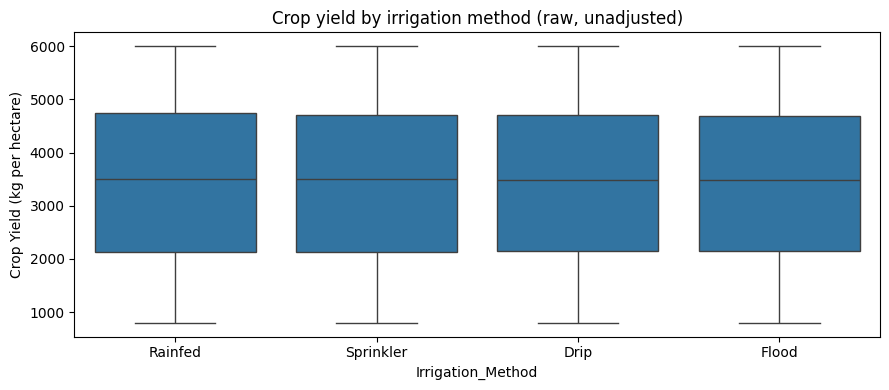

In [3]:
# Yield distribution by irrigation method
plt.figure(figsize=(9, 4))
order = df.groupby('Irrigation_Method')['Crop Yield (kg per hectare)'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Irrigation_Method', y='Crop Yield (kg per hectare)', order=order)
plt.title('Crop yield by irrigation method (raw, unadjusted)')
plt.tight_layout()
plt.show()


In [4]:
# Confounder balance check across irrigation groups
confounders = ['rainfall', 'temperature', 'humidity', 'N', 'P', 'K', 'pH']
df.groupby('Irrigation_Method')[confounders].mean().round(2)


,rainfall,temperature,humidity,N,P,K,pH
Irrigation_Method,,,,,,,
Drip,1680.46,27.57,59.66,70.90,51.44,76.46,6.46
Flood,1687.75,27.59,59.53,70.83,51.62,76.22,6.46
Rainfed,1686.15,27.52,59.67,71.16,51.52,76.40,6.47
Sprinkler,1674.66,27.55,59.68,71.36,51.42,76.15,6.47


## 4. Planned Methods

### 4a. Causal Inference
- [ ] Causal graph / DAG (DoWhy)
- [ ] Backdoor adjustment
- [ ] Instrumental variable
- [x] **Propensity score stratification**
- [ ] Other: ___

*Justification:*  
Irrigation method is a choice variable — farmers self-select based on rainfall, soil quality, and wealth. Propensity score stratification will estimate the propensity of adopting modern irrigation (drip/sprinkler vs. flood/rainfed) from the observed confounders, then compare yield within strata of similar propensity scores. This mimics a quasi-experiment by comparing farms that look alike on observable characteristics but differ in irrigation method. We will also build the underlying causal DAG in DoWhy to formally identify the backdoor set.

### 4b. Supervised Learning
- [x] **Linear / Ridge / Lasso regression** (baseline + interaction terms)
- [ ] Logistic regression
- [ ] k-Nearest Neighbors
- [ ] Support Vector Machine
- [x] **Decision Tree / Random Forest**
- [ ] Neural network
- [ ] Other: ___

*Justification:*  
Lasso regression with irrigation × soil_type interaction terms allows us to test whether the yield premium from drip irrigation is heterogeneous across soil types (e.g., larger on sandy soils that retain less moisture). A Random Forest is used as a flexible benchmark and to produce feature importance rankings that reveal which input variables most strongly predict yield.

### 4c. Unsupervised Learning / Generative Models
- [ ] K-Means clustering
- [x] **Hierarchical clustering**
- [ ] Variational autoencoder
- [ ] GAN
- [ ] Other: ___

*Justification:*  
Hierarchical clustering on crop-level yield profiles across irrigation methods produces a dendrogram showing which crops respond similarly to irrigation choices. This allows us to group crops into "irrigation-responsive" vs "irrigation-insensitive" categories — a practically useful output for advising which crops benefit most from infrastructure investment.


## 5. Evaluation Strategy

**Supervised Learning metrics:**
- Primary: **RMSE** on a held-out 20% test set (stratified by `Irrigation_Method` to preserve group balance).
- Secondary: **R²** and coefficient magnitude on Lasso interaction terms — are irrigation × soil_type coefficients statistically and practically significant?
- Baseline: mean yield of the training set; any model must outperform this naïve predictor.

**Causal Inference validation:**
- After propensity score stratification, we report the **Average Treatment Effect (ATE)** of modern vs. traditional irrigation with 95% bootstrap confidence intervals.
- **Balance check:** verify that within propensity score strata, confounder distributions are approximately equal (standardised mean differences < 0.1).
- **Sensitivity analysis**

**Unsupervised Learning metrics:**
- **Cophenetic correlation coefficient** to assess how well the dendrogram preserves pairwise distances.
- Qualitative: interpret resulting crop clusters by average yield response across irrigation types and discuss agronomic plausibility.


## 6. Work Plan

| Step | Owner | Description |
|------|-------|-------------|
| 1 | Danish | Data cleaning: drop derived collinear columns, encode categoricals, deduplicate confounders |
| 2 | Danish | EDA: yield distributions by irrigation × soil type, confounder balance table |
| 3 | Oliver | Causal inference: build DAG, estimate propensity scores (logistic regression), stratify, compute ATE |
| 4 | Danish | Supervised learning: Lasso with interactions, Random Forest, compare RMSE on test set |
| 5 | Oliver | Hierarchical clustering of crops by irrigation-yield profile; dendrogram + cluster interpretation |
| 6 | Oliver | Synthesis, sensitivity analysis, write-up |


---
## 7. Results *(complete for final submission)*

### 7a. Causal Inference

In [ ]:
# Causal inference analysis


### 7b. Supervised Learning

In [ ]:
# Supervised learning analysis


### 7c. Unsupervised / Generative

In [ ]:
# Unsupervised / generative analysis


## 8. Discussion & Conclusion *(complete for final submission)*

*Synthesise findings across all three method blocks. What does each lens reveal that the others miss? What are the limitations of your analysis?*


